# Chapter 1: Transit Routing -- The Northern Line Branch

The Northern line splits into two branches between Kennington and Euston and doesn't share a single station in between:

- **Via Charing Cross** (8 stops): Kennington, Waterloo, Embankment, Charing Cross, Leicester Square, Tottenham Court Road, Goodge Street, Warren Street, Euston
- **Via Bank** (9 stops): Kennington, Elephant and Castle, Borough, London Bridge, Bank, Moorgate, Old Street, Angel, Kings Cross St. Pancras, Euston

A shortest-path algorithm finds the optimal route once, upfront and doesn't reconsider it. [Jev](https://typesafe.ai), a structured decision model from TypeSafe AI, makes a fresh judgment at every hop instead. That difference doesn't matter much on a quiet network. It matters the moment something changes mid-journey.

This chapter builds both approaches side by side, then asks the more important question: are we even using Jev correctly?

## Prerequisites

```shell
export TYPESAFE_API_KEY="your-typesafe-key"
export CARTO_API_KEY="your-carto-key"
```

The CSV files live in the `data/` directory alongside this notebook:

```
data/
  london_stations.csv
  london_connections.csv
  london_lines.csv
```

## 1. Install dependencies

In [1]:
%pip install folium==0.19.6 \
             networkx==3.3 \
             pandas==2.2.3 \
             plotly==6.1.2 \
             typesafe-sdk==0.7.2 --quiet

Note: you may need to restart the kernel to use updated packages.


## 2. Imports and configuration

In [2]:
import folium
import networkx as nx
import numpy as np
import os
import pandas as pd
import plotly.graph_objects as go
import time

from typesafe_sdk import Choice, TypeSafeClient

In [3]:
TYPESAFE_API_KEY = os.environ["TYPESAFE_API_KEY"]
CARTO_API_KEY    = os.environ.get("CARTO_API_KEY")

if CARTO_API_KEY:
    MAP_TILES = (
        "https://{s}.basemaps.cartocdn.com/light_all/{z}/{x}/{y}.png"
        f"?key={CARTO_API_KEY}"
    )
    MAP_ATTR = (
        "&copy; <a href='https://www.openstreetmap.org/copyright'>OpenStreetMap</a>, "
        "&copy; <a href='https://carto.com/attributions'>CARTO</a>"
    )
else:
    MAP_TILES = "OpenStreetMap"
    MAP_ATTR  = None

print("Configuration set.")

Configuration set.


## 3. Load CSV files

Strip whitespace, merge line colors onto connections and drop any station with no connections.

In [4]:
stations_df    = pd.read_csv("data/london_stations.csv")
connections_df = pd.read_csv("data/london_connections.csv")
lines_df       = pd.read_csv("data/london_lines.csv")

for df in [stations_df, connections_df, lines_df]:
    df.columns = df.columns.str.strip()
    df.update(df.select_dtypes(include="object").apply(lambda c: c.str.strip()))

connections_df = connections_df.merge(lines_df, on="Tube Line", how="inner")

connected = set(connections_df["From Station"]) | set(connections_df["To Station"])
stations_df = stations_df[stations_df["Station"].isin(connected)].copy()

print(f"Stations:    {len(stations_df)}")
print(f"Connections: {len(connections_df)}")
print(f"Lines:       {len(lines_df)}")

Stations:    349
Connections: 458
Lines:       13


## 4. Build the graph

We build a NetworkX graph directly from the CSV files. Each station is a node carrying its coordinates and zone; each connection is an undirected edge carrying the line name.

In [5]:
G = nx.MultiGraph()

for _, row in stations_df.iterrows():
    G.add_node(
        row["Station"],
        lat=float(row["Latitude"]),
        lon=float(row["Longitude"]),
        zone=row["Zone"],
    )

for _, row in connections_df.iterrows():
    G.add_edge(
        row["From Station"],
        row["To Station"],
        line=row["Tube Line"],
        color=row["Color"],
    )

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

Nodes: 349
Edges: 458


## 5. The Northern line branches

Both branch station lists, used for the map and sanity checks. Neither the baseline nor the Jev pathfinder is constrained to these lists -- both work over the full graph.

In [6]:
ORIGIN      = "Kennington"
DESTINATION = "Euston"

BRANCH_CHARING_CROSS = [
    "Kennington", "Waterloo", "Embankment", "Charing Cross",
    "Leicester Square", "Tottenham Court Road", "Goodge Street",
    "Warren Street", "Euston"
]

BRANCH_BANK = [
    "Kennington", "Elephant and Castle", "Borough", "London Bridge",
    "Bank", "Moorgate", "Old Street", "Angel",
    "Kings Cross St. Pancras", "Euston"
]

known = set(G.nodes)
for branch_name, branch in [("Charing Cross branch", BRANCH_CHARING_CROSS),
                              ("Bank branch", BRANCH_BANK)]:
    missing = [s for s in branch if s not in known]
    if missing:
        print(f"WARNING -- {branch_name} has names not in the graph: {missing}")
    else:
        print(f"{branch_name}: all {len(branch)} station names verified.")

Charing Cross branch: all 9 station names verified.
Bank branch: all 10 station names verified.


## 6. Map: The Northern line branches

Both branches plotted with every station labeled. Charing Cross branch in blue, Bank branch in red.

In [7]:
def branch_map(G, cc_branch, bank_branch, origin, destination):
    all_stations = list(dict.fromkeys(cc_branch + bank_branch))
    coords = {s: (G.nodes[s]["lat"], G.nodes[s]["lon"])
              for s in all_stations if s in G.nodes}

    center_lat = sum(c[0] for c in coords.values()) / len(coords)
    center_lon = sum(c[1] for c in coords.values()) / len(coords)

    m = folium.Map(location=[center_lat, center_lon], zoom_start=13,
                   tiles=MAP_TILES, attr=MAP_ATTR)

    cc_coords   = [coords[s] for s in cc_branch   if s in coords]
    bank_coords = [coords[s] for s in bank_branch if s in coords]

    folium.PolyLine(cc_coords,   color="blue", weight=5, opacity=0.85,
                    tooltip="Charing Cross branch").add_to(m)
    folium.PolyLine(bank_coords, color="red", weight=5, opacity=0.85,
                    tooltip="Bank branch").add_to(m)

    cc_set   = set(cc_branch)
    bank_set = set(bank_branch)

    for station, coord in coords.items():
        is_origin      = station == origin
        is_destination = station == destination
        on_cc   = station in cc_set
        on_bank = station in bank_set

        if is_origin or is_destination:
            color = "green" if is_origin else "red"
            icon  = "play"  if is_origin else "flag"
            label = "Origin" if is_origin else "Destination"
            folium.Marker(
                location=coord,
                tooltip=f"<b>{station}</b><br>{label}",
                icon=folium.Icon(color=color, icon=icon, prefix="fa"),
            ).add_to(m)
        else:
            dot_color = "grey" if (on_cc and on_bank) else ("blue" if on_cc else "red")
            anchor    = "left" if on_cc and not on_bank else "right"

            folium.CircleMarker(
                location=coord, radius=6,
                color="white", weight=1.5,
                fill=True, fill_color=dot_color, fill_opacity=1.0,
                tooltip=f"<b>{station}</b>",
            ).add_to(m)

            label_html = (
                '<div style="font-size:11px;font-weight:600;color:#222;'
                'white-space:nowrap;'
                'text-shadow:1px 1px 0 #fff,-1px -1px 0 #fff,'
                '1px -1px 0 #fff,-1px 1px 0 #fff;'
                f'margin-top:8px;text-align:{anchor};">{station}</div>'
            )
            folium.Marker(
                location=coord,
                icon=folium.DivIcon(
                    html=label_html,
                    icon_size=(120, 20),
                    icon_anchor=(60, 0),
                ),
                tooltip=station,
            ).add_to(m)

    legend_html = (
        '<div style="position:fixed;bottom:40px;left:40px;z-index:1000;'
        'background:white;padding:12px 16px;border-radius:8px;'
        'box-shadow:0 2px 6px rgba(0,0,0,0.3);font-family:sans-serif;'
        'font-size:13px;line-height:2;">'
        '<b>Northern line: Kennington to Euston</b><br><br>'
        '<span style="display:inline-block;width:24px;height:4px;'
        'background:blue;margin-right:6px;vertical-align:middle;"></span>'
        'Charing Cross branch (8 stops)<br>'
        '<span style="display:inline-block;width:24px;height:4px;'
        'background:red;margin-right:6px;vertical-align:middle;"></span>'
        'Bank branch (9 stops)</div>'
    )
    m.get_root().html.add_child(folium.Element(legend_html))
    return m

branch_map(G, BRANCH_CHARING_CROSS, BRANCH_BANK, ORIGIN, DESTINATION)

## 7. Baseline: shortest path

NetworkX's `shortest_path()` finds the globally optimal route across all lines. We also run a Northern-line-only constrained version for a fair comparison with what Jev actually does.

In [8]:
start = time.time()
baseline_path    = nx.shortest_path(G, ORIGIN, DESTINATION)
baseline_elapsed = time.time() - start
baseline_hops    = len(baseline_path) - 1

print(f"Unconstrained shortest path: {ORIGIN} -> {DESTINATION}")
print(f"  Stops:   {baseline_hops}")
print(f"  Route:   {' -> '.join(baseline_path)}")
print(f"  Elapsed: {baseline_elapsed * 1000:.3f} ms")

Unconstrained shortest path: Kennington -> Euston
  Stops:   6
  Route:   Kennington -> Waterloo -> Westminster -> Green Park -> Oxford Circus -> Warren Street -> Euston
  Elapsed: 0.328 ms


In [9]:
# Build Northern-line-only subgraph manually (required for MultiGraph)
G_northern = nx.Graph()
for u, v, data in G.edges(data=True):
    if data.get("line") == "Northern":
        G_northern.add_node(u)
        G_northern.add_node(v)
        G_northern.add_edge(u, v)

start = time.time()
northern_path    = nx.shortest_path(G_northern, ORIGIN, DESTINATION)
northern_elapsed = time.time() - start
northern_hops    = len(northern_path) - 1

print(f"Northern-line-only shortest path: {ORIGIN} -> {DESTINATION}")
print(f"  Stops:   {northern_hops}")
print(f"  Route:   {' -> '.join(northern_path)}")
print(f"  Elapsed: {northern_elapsed * 1000:.3f} ms")
print(f"  Branch:  {'Charing Cross' if 'Waterloo' in northern_path else 'Bank'}")

Northern-line-only shortest path: Kennington -> Euston
  Stops:   8
  Route:   Kennington -> Waterloo -> Embankment -> Charing Cross -> Leicester Square -> Tottenham Court Road -> Goodge Street -> Warren Street -> Euston
  Elapsed: 0.036 ms
  Branch:  Charing Cross


## 8. The Jev pathfinder

Three functions:

- `get_neighbors` -- reads directly from the NetworkX graph, returning each neighbor and its line name.
- `jev_next_hop` -- one Jev `Choice` call per hop. State includes the current position, destination, path so far and any incident note.
- `jev_pathfind` -- the loop. No visited-station exclusion, so backtracking is a legitimate move if Jev decides it's the better one.

In [10]:
def get_neighbors(G, station):
    seen = set()
    result = []
    for neighbor, edges in G[station].items():
        for edge_data in edges.values():
            line = edge_data.get("line", "Unknown")
            if (neighbor, line) not in seen:
                result.append((neighbor, line))
                seen.add((neighbor, line))
    return result

In [11]:
def jev_next_hop(client, current, destination, neighbors, path_so_far,
                 incident_note=None):
    state = {
        "current_station": current,
        "destination":     destination,
        "network":         "London Underground",
        "path_so_far":     path_so_far,
    }
    if incident_note:
        state["incident"] = incident_note

    criteria = {name: line for name, line in neighbors}

    response = client.system_one(
        state=state,
        questions={
            "next_hop": Choice(
                instructions=(
                    f"Which neighboring station should we move to next, to reach "
                    f"{destination} as reliably as possible given the current state? "
                    f"Avoid revisiting stations already in path_so_far unless there "
                    f"is a clear reason to backtrack."
                ),
                criteria=criteria,
            )
        },
    )
    answer = response.choices["next_hop"]
    return answer.choice, answer.confidence

In [12]:
def jev_pathfind(G, client, origin, destination,
                 incident_note=None, incident_from=None, max_hops=25):
    path        = [origin]
    confidences = []
    current     = origin

    start = time.time()
    while current != destination and len(path) <= max_hops:
        neighbors       = get_neighbors(G, current)
        active_incident = (incident_note
                           if (incident_from and incident_from in path)
                           else None)
        choice, confidence = jev_next_hop(
            client, current, destination, neighbors,
            path_so_far=path, incident_note=active_incident,
        )
        path.append(choice)
        confidences.append(confidence)
        current = choice
    elapsed = time.time() - start

    return {
        "path":                path,
        "confidences":         confidences,
        "hops":                len(path) - 1,
        "elapsed_seconds":     elapsed,
        "reached_destination": current == destination,
    }

In [13]:
jev_client = TypeSafeClient(model="jev-1.13.0")
print("Jev client ready.")

Jev client ready.


## 9. Undisrupted run

No incident. We run once, print the route and per-hop confidence, then repeat five times to check consistency.

In [14]:
clean_run = jev_pathfind(G, jev_client, ORIGIN, DESTINATION)

print(f"Jev pathfinder (no disruption): {ORIGIN} -> {DESTINATION}")
print(f"  Stops:   {clean_run['hops']}")
print(f"  Route:   {' -> '.join(clean_run['path'])}")
print(f"  Elapsed: {clean_run['elapsed_seconds'] * 1000:.1f} ms")
print(f"  Reached: {clean_run['reached_destination']}")
print()
print("Per-hop confidence:")
for station, conf in zip(clean_run["path"][1:], clean_run["confidences"]):
    print(f"  -> {station}: {conf:.2f}")

Jev pathfinder (no disruption): Kennington -> Euston
  Stops:   9
  Route:   Kennington -> Elephant and Castle -> Borough -> London Bridge -> Bank -> Moorgate -> Old Street -> Angel -> Kings Cross St. Pancras -> Euston
  Elapsed: 2318.9 ms
  Reached: True

Per-hop confidence:
  -> Elephant and Castle: 0.30
  -> Borough: 0.58
  -> London Bridge: 0.89
  -> Bank: 0.55
  -> Moorgate: 0.85
  -> Old Street: 0.52
  -> Angel: 0.87
  -> Kings Cross St. Pancras: 0.90
  -> Euston: 0.60


### Per-hop confidence: undisrupted run

Jev's confidence at each station along the route. The low score at the branch decision point (Kennington) and at Euston reflects genuine uncertainty at the open-ended moments of the journey. Confidence mid-route, where the path is clear, is consistently higher.

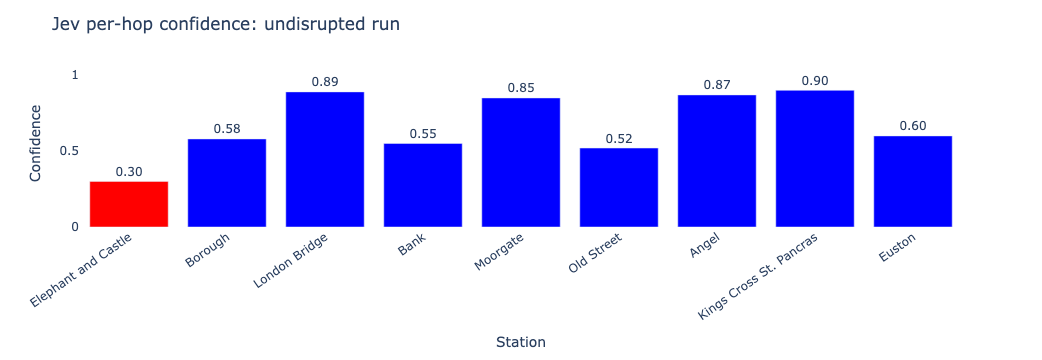

In [15]:
stations_clean = clean_run["path"][1:]
confs_clean    = clean_run["confidences"]

fig1 = go.Figure(go.Bar(
    x=stations_clean,
    y=confs_clean,
    marker_color=["red" if c < 0.50 else "blue" for c in confs_clean],
    text=[f"{c:.2f}" for c in confs_clean],
    textposition="outside",
))
fig1.update_layout(
    title="Jev per-hop confidence: undisrupted run",
    xaxis_title="Station",
    yaxis_title="Confidence",
    yaxis=dict(range=[0, 1.1]),
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(size=12),
    margin=dict(t=60, b=120),
)
fig1.update_xaxes(tickangle=-35)
fig1.show()

In [16]:
N_RUNS  = 5
results = []

for i in range(N_RUNS):
    run = jev_pathfind(G, jev_client, ORIGIN, DESTINATION)
    results.append({
        "run":             i + 1,
        "hops":            run["hops"],
        "branch":          "Charing Cross" if "Waterloo" in run["path"] else "Bank",
        "reached":         run["reached_destination"],
        "elapsed_ms":      round(run["elapsed_seconds"] * 1000, 1),
        "hop1_confidence": round(run["confidences"][0], 2) if run["confidences"] else None,
        "route":           " -> ".join(run["path"]),
    })
    print(f"Run {i + 1}: {run['hops']} hops, "
          f"{'Charing Cross' if 'Waterloo' in run['path'] else 'Bank'} branch, "
          f"hop-1 confidence: {run['confidences'][0]:.2f}")

pd.DataFrame(results)

Run 1: 9 hops, Bank branch, hop-1 confidence: 0.36
Run 2: 9 hops, Bank branch, hop-1 confidence: 0.32
Run 3: 9 hops, Bank branch, hop-1 confidence: 0.35
Run 4: 9 hops, Bank branch, hop-1 confidence: 0.36
Run 5: 9 hops, Bank branch, hop-1 confidence: 0.34


,run,hops,branch,reached,elapsed_ms,hop1_confidence,route
0,1,9,Bank,True,2080.8,0.36,Kennington -> Elephant and Castle -> Borough -...
1,2,9,Bank,True,1968.0,0.32,Kennington -> Elephant and Castle -> Borough -...
2,3,9,Bank,True,1919.9,0.35,Kennington -> Elephant and Castle -> Borough -...
3,4,9,Bank,True,2221.5,0.36,Kennington -> Elephant and Castle -> Borough -...
4,5,9,Bank,True,2147.7,0.34,Kennington -> Elephant and Castle -> Borough -...


## 10. The disruption

The traveler is at Leicester Square, four stops into the Charing Cross route, when word comes through that Warren Street is suspended ahead. This is deliberately ambiguous -- the kind of update a real commuter actually gets. Pushing on costs nothing if it clears in time. Backtracking and rerouting via Bank is a known, longer alternative.

In [17]:
INCIDENT_NOTE = (
    "Severe delays reported on the Charing Cross branch. Warren Street is "
    "currently suspended due to a signal failure. Engineers are on site. "
    "No confirmed reopening time yet."
)
INCIDENT_FROM = "Leicester Square"

disrupted_run = jev_pathfind(
    G, jev_client, ORIGIN, DESTINATION,
    incident_note=INCIDENT_NOTE,
    incident_from=INCIDENT_FROM,
)

print(f"Jev pathfinder (disrupted at {INCIDENT_FROM}): {ORIGIN} -> {DESTINATION}")
print(f"  Stops:   {disrupted_run['hops']}")
print(f"  Route:   {' -> '.join(disrupted_run['path'])}")
print(f"  Elapsed: {disrupted_run['elapsed_seconds'] * 1000:.1f} ms")
print(f"  Reached: {disrupted_run['reached_destination']}")
print()
print("Per-hop confidence:")
for station, conf in zip(disrupted_run["path"][1:], disrupted_run["confidences"]):
    print(f"  -> {station}: {conf:.2f}")

Jev pathfinder (disrupted at Leicester Square): Kennington -> Euston
  Stops:   9
  Route:   Kennington -> Elephant and Castle -> Borough -> London Bridge -> Bank -> Moorgate -> Old Street -> Angel -> Kings Cross St. Pancras -> Euston
  Elapsed: 2018.2 ms
  Reached: True

Per-hop confidence:
  -> Elephant and Castle: 0.32
  -> Borough: 0.51
  -> London Bridge: 0.87
  -> Bank: 0.56
  -> Moorgate: 0.85
  -> Old Street: 0.46
  -> Angel: 0.90
  -> Kings Cross St. Pancras: 0.92
  -> Euston: 0.48


## 11. Disrupted run stability (5 runs)

Same loop as the undisrupted run, with the incident note active throughout.

In [18]:
disrupted_results = []
for i in range(N_RUNS):
    run = jev_pathfind(
        G, jev_client, ORIGIN, DESTINATION,
        incident_note=INCIDENT_NOTE,
        incident_from=INCIDENT_FROM,
    )
    disrupted_results.append({
        "run":             i + 1,
        "hops":            run["hops"],
        "branch":          "Charing Cross" if "Waterloo" in run["path"] else "Bank",
        "reached":         run["reached_destination"],
        "elapsed_ms":      round(run["elapsed_seconds"] * 1000, 1),
        "hop1_confidence": round(run["confidences"][0], 2) if run["confidences"] else None,
        "route":           " -> ".join(run["path"]),
    })
    print(f"Run {i + 1}: {run['hops']} hops, "
          f"{'Charing Cross' if 'Waterloo' in run['path'] else 'Bank'} branch, "
          f"hop-1 confidence: {run['confidences'][0]:.2f}")

pd.DataFrame(disrupted_results)

Run 1: 9 hops, Bank branch, hop-1 confidence: 0.36
Run 2: 9 hops, Bank branch, hop-1 confidence: 0.34
Run 3: 9 hops, Bank branch, hop-1 confidence: 0.36
Run 4: 9 hops, Bank branch, hop-1 confidence: 0.38
Run 5: 9 hops, Bank branch, hop-1 confidence: 0.37


,run,hops,branch,reached,elapsed_ms,hop1_confidence,route
0,1,9,Bank,True,2051.2,0.36,Kennington -> Elephant and Castle -> Borough -...
1,2,9,Bank,True,1956.0,0.34,Kennington -> Elephant and Castle -> Borough -...
2,3,9,Bank,True,1897.2,0.36,Kennington -> Elephant and Castle -> Borough -...
3,4,9,Bank,True,2177.1,0.38,Kennington -> Elephant and Castle -> Borough -...
4,5,9,Bank,True,2235.3,0.37,Kennington -> Elephant and Castle -> Borough -...


### Per-hop confidence: clean vs disrupted overlay

The two runs are nearly identical. The incident note had no measurable effect on Jev's confidence at any hop -- because the pathfinder had already committed to the Bank branch at Kennington, before Leicester Square was ever in the path.

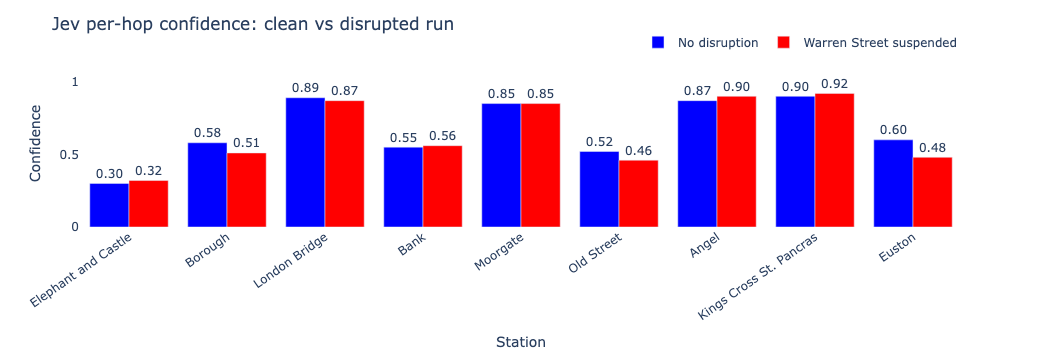

In [19]:
stations_dis = disrupted_run["path"][1:]
confs_dis    = disrupted_run["confidences"]

fig2 = go.Figure()
fig2.add_trace(go.Bar(
    name="No disruption",
    x=stations_clean, y=confs_clean,
    marker_color="blue",
    text=[f"{c:.2f}" for c in confs_clean],
    textposition="outside",
))
fig2.add_trace(go.Bar(
    name="Warren Street suspended",
    x=stations_dis, y=confs_dis,
    marker_color="red",
    text=[f"{c:.2f}" for c in confs_dis],
    textposition="outside",
))
fig2.update_layout(
    title="Jev per-hop confidence: clean vs disrupted run",
    xaxis_title="Station",
    yaxis_title="Confidence",
    yaxis=dict(range=[0, 1.15]),
    barmode="group",
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(size=12),
    margin=dict(t=60, b=120),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
)
fig2.update_xaxes(tickangle=-35)
fig2.show()

## 12. Experiment: start from Waterloo

In [20]:
WATERLOO_RUNS   = 5
waterloo_results = []

for i in range(WATERLOO_RUNS):
    run = jev_pathfind(G, jev_client, "Waterloo", DESTINATION)
    waterloo_results.append({
        "run":             i + 1,
        "hops":            run["hops"],
        "reached":         run["reached_destination"],
        "elapsed_ms":      round(run["elapsed_seconds"] * 1000, 1),
        "hop1_confidence": round(run["confidences"][0], 2) if run["confidences"] else None,
        "route":           " -> ".join(run["path"]),
    })
    print(f"Run {i + 1}: {run['hops']} hops, "
          f"reached: {run['reached_destination']}, "
          f"hop-1 confidence: {run['confidences'][0]:.2f}")
    print(f"  Route: {' -> '.join(run['path'])}")

print()
wl_path = nx.shortest_path(G, "Waterloo", DESTINATION)
print(f"NetworkX shortest path from Waterloo: {len(wl_path)-1} hops")
print(f"  Route: {' -> '.join(wl_path)}")

pd.DataFrame(waterloo_results)

Run 1: 7 hops, reached: True, hop-1 confidence: 0.28
  Route: Waterloo -> Embankment -> Charing Cross -> Leicester Square -> Tottenham Court Road -> Goodge Street -> Warren Street -> Euston
Run 2: 7 hops, reached: True, hop-1 confidence: 0.29
  Route: Waterloo -> Embankment -> Charing Cross -> Leicester Square -> Tottenham Court Road -> Goodge Street -> Warren Street -> Euston
Run 3: 7 hops, reached: True, hop-1 confidence: 0.27
  Route: Waterloo -> Embankment -> Charing Cross -> Leicester Square -> Tottenham Court Road -> Goodge Street -> Warren Street -> Euston
Run 4: 7 hops, reached: True, hop-1 confidence: 0.30
  Route: Waterloo -> Embankment -> Charing Cross -> Leicester Square -> Tottenham Court Road -> Goodge Street -> Warren Street -> Euston
Run 5: 7 hops, reached: True, hop-1 confidence: 0.24
  Route: Waterloo -> Embankment -> Charing Cross -> Leicester Square -> Tottenham Court Road -> Goodge Street -> Warren Street -> Euston

NetworkX shortest path from Waterloo: 5 hops
  Ro

,run,hops,reached,elapsed_ms,hop1_confidence,route
0,1,7,True,1847.2,0.28,Waterloo -> Embankment -> Charing Cross -> Lei...
1,2,7,True,1808.2,0.29,Waterloo -> Embankment -> Charing Cross -> Lei...
2,3,7,True,1741.7,0.27,Waterloo -> Embankment -> Charing Cross -> Lei...
3,4,7,True,1616.2,0.30,Waterloo -> Embankment -> Charing Cross -> Lei...
4,5,7,True,1568.8,0.24,Waterloo -> Embankment -> Charing Cross -> Lei...


## 13. Experiment: reverse journey (Euston to Kennington)

In [21]:
REVERSE_RUNS    = 5
reverse_results = []

for i in range(REVERSE_RUNS):
    run = jev_pathfind(G, jev_client, DESTINATION, ORIGIN)
    reverse_results.append({
        "run":             i + 1,
        "hops":            run["hops"],
        "branch":          "Charing Cross" if "Waterloo" in run["path"] else "Bank",
        "reached":         run["reached_destination"],
        "elapsed_ms":      round(run["elapsed_seconds"] * 1000, 1),
        "hop1_confidence": round(run["confidences"][0], 2) if run["confidences"] else None,
        "route":           " -> ".join(run["path"]),
    })
    print(f"Run {i + 1}: {run['hops']} hops, "
          f"{'Charing Cross' if 'Waterloo' in run['path'] else 'Bank'} branch, "
          f"hop-1 confidence: {run['confidences'][0]:.2f}")

print()
rev_path = nx.shortest_path(G, DESTINATION, ORIGIN)
print(f"NetworkX shortest path {DESTINATION} to {ORIGIN}: {len(rev_path)-1} hops")
print(f"  Route: {' -> '.join(rev_path)}")

pd.DataFrame(reverse_results)

Run 1: 7 hops, Charing Cross branch, hop-1 confidence: 0.25
Run 2: 8 hops, Charing Cross branch, hop-1 confidence: 0.23
Run 3: 8 hops, Charing Cross branch, hop-1 confidence: 0.20
Run 4: 8 hops, Charing Cross branch, hop-1 confidence: 0.20
Run 5: 8 hops, Charing Cross branch, hop-1 confidence: 0.23

NetworkX shortest path Euston to Kennington: 6 hops
  Route: Euston -> Warren Street -> Oxford Circus -> Green Park -> Westminster -> Waterloo -> Kennington


,run,hops,branch,reached,elapsed_ms,hop1_confidence,route
0,1,7,Charing Cross,True,1572.8,0.25,Euston -> Warren Street -> Oxford Circus -> Pi...
1,2,8,Charing Cross,True,1880.6,0.23,Euston -> Warren Street -> Goodge Street -> To...
2,3,8,Charing Cross,True,1734.6,0.20,Euston -> Warren Street -> Goodge Street -> To...
3,4,8,Charing Cross,True,1843.5,0.20,Euston -> Warren Street -> Goodge Street -> To...
4,5,8,Charing Cross,True,1771.1,0.23,Euston -> Warren Street -> Goodge Street -> To...


## 14. Experiment: softer incident note

In [22]:
INCIDENT_NOTE_SOFT = (
    "Minor delays reported on the Charing Cross branch. Warren Street has "
    "a brief signal failure but is expected to reopen within 10 minutes. "
    "Service should resume shortly."
)

SOFT_RUNS    = 5
soft_results = []

for i in range(SOFT_RUNS):
    run = jev_pathfind(
        G, jev_client, ORIGIN, DESTINATION,
        incident_note=INCIDENT_NOTE_SOFT,
        incident_from=INCIDENT_FROM,
    )
    soft_results.append({
        "run":             i + 1,
        "hops":            run["hops"],
        "branch":          "Charing Cross" if "Waterloo" in run["path"] else "Bank",
        "reached":         run["reached_destination"],
        "elapsed_ms":      round(run["elapsed_seconds"] * 1000, 1),
        "hop1_confidence": round(run["confidences"][0], 2) if run["confidences"] else None,
        "route":           " -> ".join(run["path"]),
    })
    print(f"Run {i + 1}: {run['hops']} hops, "
          f"{'Charing Cross' if 'Waterloo' in run['path'] else 'Bank'} branch, "
          f"hop-1 confidence: {run['confidences'][0]:.2f}")

pd.DataFrame(soft_results)

Run 1: 9 hops, Bank branch, hop-1 confidence: 0.39
Run 2: 9 hops, Bank branch, hop-1 confidence: 0.39
Run 3: 9 hops, Bank branch, hop-1 confidence: 0.34
Run 4: 9 hops, Bank branch, hop-1 confidence: 0.37
Run 5: 9 hops, Bank branch, hop-1 confidence: 0.40


,run,hops,branch,reached,elapsed_ms,hop1_confidence,route
0,1,9,Bank,True,2102.6,0.39,Kennington -> Elephant and Castle -> Borough -...
1,2,9,Bank,True,2311.5,0.39,Kennington -> Elephant and Castle -> Borough -...
2,3,9,Bank,True,1981.2,0.34,Kennington -> Elephant and Castle -> Borough -...
3,4,9,Bank,True,2150.2,0.37,Kennington -> Elephant and Castle -> Borough -...
4,5,9,Bank,True,2144.5,0.40,Kennington -> Elephant and Castle -> Borough -...


## 15. Full comparison

The four scenarios side by side. NetworkX shortest path timing is sub-millisecond.

In [23]:
full_comparison = pd.DataFrame([
    {
        "scenario":  "NetworkX shortest path (unconstrained)",
        "hops":      baseline_hops,
        "elapsed_ms": round(baseline_elapsed * 1000, 3),
        "route":     " -> ".join(baseline_path),
    },
    {
        "scenario":  "NetworkX shortest path (Northern line only)",
        "hops":      northern_hops,
        "elapsed_ms": round(northern_elapsed * 1000, 3),
        "route":     " -> ".join(northern_path),
    },
    {
        "scenario":  "Jev pathfinder (no disruption)",
        "hops":      clean_run["hops"],
        "elapsed_ms": round(clean_run["elapsed_seconds"] * 1000, 1),
        "route":     " -> ".join(clean_run["path"]),
    },
    {
        "scenario":  "Jev pathfinder (Warren Street suspended)",
        "hops":      disrupted_run["hops"],
        "elapsed_ms": round(disrupted_run["elapsed_seconds"] * 1000, 1),
        "route":     " -> ".join(disrupted_run["path"]),
    },
])

full_comparison

,scenario,hops,elapsed_ms,route
0,NetworkX shortest path (unconstrained),6,0.328,Kennington -> Waterloo -> Westminster -> Green...
1,NetworkX shortest path (Northern line only),8,0.036,Kennington -> Waterloo -> Embankment -> Charin...
2,Jev pathfinder (no disruption),9,2318.900,Kennington -> Elephant and Castle -> Borough -...
3,Jev pathfinder (Warren Street suspended),9,2018.200,Kennington -> Elephant and Castle -> Borough -...


## 16. Map: Three routes compared

The unconstrained shortest path (grey), the Northern-line-only shortest path (blue, Charing Cross branch) and the Jev pathfinder route (red, Bank branch). All three start at Kennington and end at Euston but take meaningfully different paths.

In [24]:
def route_coords(G, path):
    return [(s, (G.nodes[s]["lat"], G.nodes[s]["lon"]))
            for s in path if s in G.nodes]

def three_route_map(G, baseline_path, northern_path, jev_path, origin, destination):
    routes = {
        "Shortest path (unconstrained)": {"path": baseline_path, "color": "grey"},
        "Shortest path (Northern line)": {"path": northern_path, "color": "blue"},
        "Jev pathfinder":                {"path": jev_path,      "color": "red"},
    }

    all_coords = [coord for route in routes.values()
                  for _, coord in route_coords(G, route["path"])]
    center_lat = sum(c[0] for c in all_coords) / len(all_coords)
    center_lon = sum(c[1] for c in all_coords) / len(all_coords)

    m = folium.Map(location=[center_lat, center_lon], zoom_start=13,
                   tiles=MAP_TILES, attr=MAP_ATTR)

    for name, route in routes.items():
        sc = route_coords(G, route["path"])
        folium.PolyLine(
            locations=[c for _, c in sc],
            color=route["color"], weight=4, opacity=0.85, tooltip=name,
        ).add_to(m)

    marked = {}
    for name, route in routes.items():
        for station, coord in route_coords(G, route["path"]):
            if station == origin:
                if station not in marked:
                    folium.Marker(location=coord,
                        tooltip=f"<b>{station}</b><br>Origin",
                        icon=folium.Icon(color="green", icon="play", prefix="fa"),
                    ).add_to(m)
                    marked[station] = True
            elif station == destination:
                if station not in marked:
                    folium.Marker(location=coord,
                        tooltip=f"<b>{station}</b><br>Destination",
                        icon=folium.Icon(color="red", icon="flag", prefix="fa"),
                    ).add_to(m)
                    marked[station] = True
            else:
                mk = f"{station}|{name}"
                if mk not in marked:
                    folium.CircleMarker(
                        location=coord, radius=5,
                        color="white", weight=1,
                        fill=True, fill_color=route["color"], fill_opacity=0.9,
                        tooltip=f"<b>{station}</b><br>{name}",
                    ).add_to(m)
                    marked[mk] = True
                if station not in marked:
                    label_html = (
                        '<div style="font-size:10px;font-weight:600;color:#222;'
                        'white-space:nowrap;'
                        'text-shadow:1px 1px 0 #fff,-1px -1px 0 #fff,'
                        '1px -1px 0 #fff,-1px 1px 0 #fff;'
                        f'margin-top:8px;">{station}</div>'
                    )
                    folium.Marker(
                        location=coord,
                        icon=folium.DivIcon(
                            html=label_html,
                            icon_size=(130, 20), icon_anchor=(65, 0),
                        ),
                        tooltip=station,
                    ).add_to(m)
                    marked[station] = True

    legend_items = "".join(
        '<span style="display:inline-block;width:24px;height:4px;'
        f'background:{r["color"]};margin-right:6px;vertical-align:middle;"></span>'
        f'{n}<br>'
        for n, r in routes.items()
    )
    legend_html = (
        '<div style="position:fixed;bottom:40px;left:40px;z-index:1000;'
        'background:white;padding:12px 16px;border-radius:8px;'
        'box-shadow:0 2px 6px rgba(0,0,0,0.3);font-family:sans-serif;'
        f'font-size:13px;line-height:2;"><b>{origin} to {destination}</b>'
        f'<br><br>{legend_items}</div>'
    )
    m.get_root().html.add_child(folium.Element(legend_html))
    return m

three_route_map(G, baseline_path, northern_path, clean_run["path"], ORIGIN, DESTINATION)

## 17. Reflection: are we using Jev fairly?

Looking back at the sequential pathfinding experiments, the answer is probably not.

TypeSafe describe Jev as being for "System One" decisions: fast, atomic, well-scoped judgments. Their own examples are things like routing a support ticket, scoring urgency, detecting whether a refund was issued. The docs are explicit: each question should be "the kind of judgment a highly knowledgeable person could make in a few seconds given the right context."

What we asked Jev to do instead was act as a sequential planning agent, making a chain of dependent decisions over a spatial network it had to reason about from scratch at every hop. The results reflect that mismatch:

- The Waterloo experiment produced highly variable hop counts across 5 runs, with confidence at hop 1 dropping significantly. Without a clear branch decision to anchor on, the problem became underspecified.
- The directional asymmetry (Bank branch northbound, Charing Cross southbound) is likely a training data artifact rather than genuine geographic reasoning.
- The incident note had no measurable effect on branch choice or confidence, consistent with a model that wasn't doing situational reasoning so much as pattern matching on network topology.

None of this means Jev is a weak model. It means we picked the wrong problem shape. A fairer test uses Jev the way it was designed: one decision, clear options, rich structured state. The next section does exactly that.

## 18. Part 2: Branch triage -- the right problem shape

Instead of asking Jev to plan a route hop by hop, we ask it to make one decision: at Kennington, which branch should a passenger take?

We build a structured state object describing the live condition of both branches and ask Jev a single `Choice` question with two options. One call, clear state, two options. That's the shape of problem Jev was built for.

### Branch state

In [25]:
def reset_disruptions(G):
    for node in G.nodes:
        G.nodes[node]["active"]        = True
        G.nodes[node]["delay_minutes"] = 0

def set_disruption(G, disruptions):
    reset_disruptions(G)
    for d in disruptions:
        G.nodes[d["name"]]["active"]        = d["active"]
        G.nodes[d["name"]]["delay_minutes"] = d["delay_minutes"]

def get_branch_state(G, branch_stations):
    return [
        {
            "name":          s,
            "active":        G.nodes[s].get("active", True),
            "delay_minutes": G.nodes[s].get("delay_minutes", 0),
        }
        for s in branch_stations if s in G.nodes
    ]

reset_disruptions(G)
print("Disruption state reset.")

Disruption state reset.


### Jev branch triage

In [26]:
def jev_branch_triage(client, cc_stations, bank_stations, destination):
    def branch_summary(stations):
        suspended = [s["name"] for s in stations if not s["active"]]
        delayed   = [s for s in stations if s["active"] and s["delay_minutes"] > 0]
        parts = []
        if suspended:
            parts.append(f"Suspended: {', '.join(suspended)}.")
        if delayed:
            parts.append(
                "Delays: " +
                ", ".join(f"{s['name']} ({s['delay_minutes']} min)" for s in delayed) + "."
            )
        if not parts:
            parts.append("All stations clear.")
        return " ".join(parts)

    state = {
        "current_station":      "Kennington",
        "destination":          destination,
        "network":              "London Underground, Northern line",
        "charing_cross_branch": branch_summary(cc_stations),
        "bank_branch":          branch_summary(bank_stations),
    }

    response = client.system_one(
        state=state,
        questions={
            "branch": Choice(
                instructions=(
                    "Which branch should the passenger take from Kennington "
                    "to reach Euston as reliably as possible given the current "
                    "state of both branches?"
                ),
                criteria={
                    "Charing Cross": (
                        "Via Waterloo, Embankment, Charing Cross, Leicester Square, "
                        "Tottenham Court Road, Goodge Street, Warren Street. "
                        "8 stops on the Northern line."
                    ),
                    "Bank": (
                        "Via Elephant and Castle, Borough, London Bridge, Bank, "
                        "Moorgate, Old Street, Angel, Kings Cross St. Pancras. "
                        "9 stops on the Northern line."
                    ),
                },
            )
        },
    )
    answer = response.choices["branch"]
    return answer.choice, answer.confidence, state

### Four disruption scenarios

We run each scenario three times to check consistency, since we've learned from the pathfinding experiments that individual runs can vary.

In [27]:
CC_STATIONS   = [s for s in BRANCH_CHARING_CROSS if s not in (ORIGIN, DESTINATION)]
BANK_STATIONS = [s for s in BRANCH_BANK          if s not in (ORIGIN, DESTINATION)]

SCENARIOS = [
    {"label": "No disruption",                                   "disruptions": []},
    {"label": "Mild: Goodge Street delayed 5 min",               "disruptions": [
        {"name": "Goodge Street", "active": True,  "delay_minutes": 5}]},
    {"label": "Severe: Warren Street suspended",                 "disruptions": [
        {"name": "Warren Street", "active": False, "delay_minutes": 0}]},
    {"label": "Critical: Warren Street and Goodge Street out",   "disruptions": [
        {"name": "Warren Street", "active": False, "delay_minutes": 0},
        {"name": "Goodge Street", "active": False, "delay_minutes": 0}]},
]

TRIAGE_RUNS    = 3
triage_results = []

for scenario in SCENARIOS:
    set_disruption(G, scenario["disruptions"])
    cc_stations   = get_branch_state(G, CC_STATIONS)
    bank_stations = get_branch_state(G, BANK_STATIONS)

    for run in range(1, TRIAGE_RUNS + 1):
        t0 = time.time()
        choice, confidence, state = jev_branch_triage(
            jev_client, cc_stations, bank_stations, DESTINATION
        )
        elapsed = (time.time() - t0) * 1000
        triage_results.append({
            "scenario":   scenario["label"],
            "run":        run,
            "choice":     choice,
            "confidence": round(confidence, 2),
            "elapsed_ms": round(elapsed, 1),
            "cc_state":   state["charing_cross_branch"],
            "bank_state": state["bank_branch"],
        })
        print(f"{scenario['label']} | Run {run}: {choice} "
              f"(confidence: {confidence:.2f}, {elapsed:.0f} ms)")
    print()

reset_disruptions(G)

No disruption | Run 1: Charing Cross (confidence: 0.74, 221 ms)
No disruption | Run 2: Charing Cross (confidence: 0.69, 197 ms)
No disruption | Run 3: Charing Cross (confidence: 0.79, 197 ms)

Mild: Goodge Street delayed 5 min | Run 1: Bank (confidence: 0.87, 196 ms)
Mild: Goodge Street delayed 5 min | Run 2: Bank (confidence: 0.87, 220 ms)
Mild: Goodge Street delayed 5 min | Run 3: Bank (confidence: 0.86, 340 ms)

Severe: Warren Street suspended | Run 1: Bank (confidence: 0.92, 219 ms)
Severe: Warren Street suspended | Run 2: Bank (confidence: 0.91, 202 ms)
Severe: Warren Street suspended | Run 3: Bank (confidence: 0.92, 387 ms)

Critical: Warren Street and Goodge Street out | Run 1: Bank (confidence: 0.92, 409 ms)
Critical: Warren Street and Goodge Street out | Run 2: Bank (confidence: 0.93, 290 ms)
Critical: Warren Street and Goodge Street out | Run 3: Bank (confidence: 0.94, 324 ms)



### Triage results

In [28]:
triage_df = pd.DataFrame(triage_results)

summary = (
    triage_df
    .groupby("scenario")
    .agg(
        choice         =("choice",     lambda x: x.iloc[0] if x.nunique() == 1 else "Mixed"),
        unanimous      =("choice",     lambda x: x.nunique() == 1),
        mean_confidence=("confidence", "mean"),
        mean_elapsed_ms=("elapsed_ms", "mean"),
    )
    .reset_index()
)

scenario_order = [s["label"] for s in SCENARIOS]
summary["scenario"] = pd.Categorical(summary["scenario"],
                                      categories=scenario_order, ordered=True)
summary = summary.sort_values("scenario").reset_index(drop=True)
summary["mean_confidence"]  = summary["mean_confidence"].round(2)
summary["mean_elapsed_ms"]  = summary["mean_elapsed_ms"].round(1)

print("Branch triage summary:")
print(summary.to_string(index=False))
print()
triage_df

Branch triage summary:
                                     scenario        choice  unanimous  mean_confidence  mean_elapsed_ms
                                No disruption Charing Cross       True             0.74            204.9
            Mild: Goodge Street delayed 5 min          Bank       True             0.87            251.8
              Severe: Warren Street suspended          Bank       True             0.92            269.3
Critical: Warren Street and Goodge Street out          Bank       True             0.93            341.0



,scenario,run,choice,confidence,elapsed_ms,cc_state,bank_state
0,No disruption,1,Charing Cross,0.74,221.2,All stations clear.,All stations clear.
1,No disruption,2,Charing Cross,0.69,196.6,All stations clear.,All stations clear.
2,No disruption,3,Charing Cross,0.79,196.9,All stations clear.,All stations clear.
3,Mild: Goodge Street delayed 5 min,1,Bank,0.87,195.5,Delays: Goodge Street (5 min).,All stations clear.
4,Mild: Goodge Street delayed 5 min,2,Bank,0.87,220.0,Delays: Goodge Street (5 min).,All stations clear.
5,Mild: Goodge Street delayed 5 min,3,Bank,0.86,339.8,Delays: Goodge Street (5 min).,All stations clear.
6,Severe: Warren Street suspended,1,Bank,0.92,219.5,Suspended: Warren Street.,All stations clear.
7,Severe: Warren Street suspended,2,Bank,0.91,201.7,Suspended: Warren Street.,All stations clear.
8,Severe: Warren Street suspended,3,Bank,0.92,386.6,Suspended: Warren Street.,All stations clear.
9,Critical: Warren Street and Goodge Street out,1,Bank,0.92,408.8,"Suspended: Goodge Street, Warren Street.",All stations clear.


### Branch triage confidence progression

As disruption severity increases on the Charing Cross branch, Jev's confidence in choosing Bank rises cleanly. With both branches clear it reflects a genuine but not overwhelming preference for Charing Cross (the shorter route). By the time two stations are suspended the choice is unambiguous.

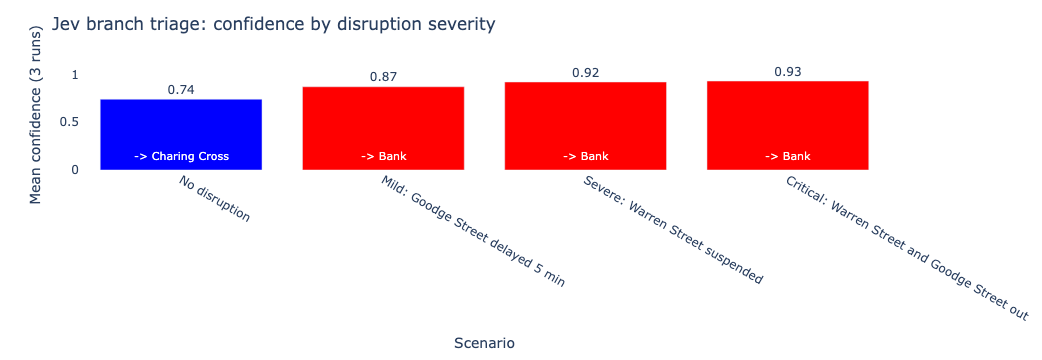

In [29]:
scenario_labels = summary["scenario"].tolist()
conf_values     = summary["mean_confidence"].tolist()
choices         = summary["choice"].tolist()
choice_colors   = ["blue" if c == "Charing Cross" else "red" for c in choices]

fig3 = go.Figure()
fig3.add_trace(go.Bar(
    x=scenario_labels,
    y=conf_values,
    marker_color=choice_colors,
    text=[f"{v:.2f}" for v in conf_values],
    textposition="outside",
))

for i, (label, choice, conf) in enumerate(zip(scenario_labels, choices, conf_values)):
    fig3.add_annotation(
        x=label,
        y=0.05,  # near the bottom of the bar
        text=f"-> {choice}",
        showarrow=False,
        font=dict(size=11, color="white"),
        yanchor="bottom",
    )

fig3.update_layout(
    title="Jev branch triage: confidence by disruption severity",
    xaxis_title="Scenario",
    yaxis_title="Mean confidence (3 runs)",
    yaxis=dict(range=[0, 1.15]),
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(size=12),
    margin=dict(t=60, b=40),
    showlegend=False,
)
fig3.show()

## 19. Summary

This chapter explored two different ways to use Jev on the London Underground graph, and they tell quite different stories.

### Part 1: Sequential pathfinding (the wrong problem shape)

Using Jev as a hop-by-hop planning agent produced valid routes but inconsistent ones. Across multiple northbound runs from Kennington to Euston it consistently chose the Bank branch over the Northern-line-optimal Charing Cross route, with low hop-1 confidence throughout. The disruption experiment was the most revealing: the incident note made no measurable difference to branch choice or confidence, because Jev had already committed to the Bank branch before Leicester Square was ever reached. The Waterloo experiment showed what happens when the problem becomes underspecified: hop counts varying widely and confidence dropping significantly.

That's not a failure of the model. It's a mismatch between the problem shape and what the model was designed for.

### Part 2: Branch triage (the right problem shape)

Reframing the problem as a single atomic decision -- which branch should a passenger take given the current state of both -- produced exactly what TypeSafe claim Jev delivers: consistent choices with confidence scores that respond meaningfully to the underlying state. With both branches clear it consistently chose Charing Cross, the shorter route. As disruption severity increased the choice shifted to Bank and confidence rose with it, reaching its highest point when two stations were suspended. All runs were unanimous. Latency was well under 500 milliseconds per call.

### The right architecture

A shortest-path algorithm is exact, instant and optimal within whatever constraints you give it. Jev returns calibrated confidence alongside its answer and responds to live state. They solve different problems, and together they're more useful than either one alone: the algorithm finds the route, Jev decides which route is worth taking right now.